In [1]:
import time
import random
import math
import itertools
import heapq
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import os
os.makedirs('images', exist_ok=True)

plt.rcParams.update({'figure.figsize': (12, 5), 'axes.grid': True, 'font.size': 11})
print('Setup complete ✓')

Setup complete ✓


---
## Task 1 — Divide and Conquer Algorithms

Algorithms implemented:
- **Binary Search** — O(log n)
- **Merge Sort** — O(n log n)
- **Quick Sort** — O(n log n) average
- **Maximum Subarray (D&C)** — O(n log n)

**Core idea:** Split the problem into independent halves, solve each recursively, combine results.

In [2]:
# ── 1A. Binary Search ────────────────────────────────────────────────────────
def binary_search(arr, target):
    """
    Repeatedly halve the search space.
    Precondition: arr must be sorted.
    Time: O(log n)  |  Space: O(1)
    """
    low, high = 0, len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            low = mid + 1       # target is in right half
        else:
            high = mid - 1      # target is in left half
    return -1


# ── 1B. Merge Sort ───────────────────────────────────────────────────────────
def merge_sort(arr):
    """
    Divide array in half, sort each half, merge sorted halves.
    Time: O(n log n)  |  Space: O(n)
    """
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    left  = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    return _merge(left, right)

def _merge(left, right):
    """Merge two sorted lists into one sorted list."""
    result, i, j = [], 0, 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i]);  i += 1
        else:
            result.append(right[j]); j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result


# ── 1C. Quick Sort ───────────────────────────────────────────────────────────
def quick_sort(arr):
    """
    Choose pivot, partition into < pivot, == pivot, > pivot, recurse.
    Median-of-array pivot reduces worst-case probability.
    Time: O(n log n) avg, O(n²) worst  |  Space: O(log n)
    """
    if len(arr) <= 1:
        return arr
    pivot = arr[len(arr) // 2]
    left  = [x for x in arr if x < pivot]
    mid   = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    return quick_sort(left) + mid + quick_sort(right)


# ── 1D. Maximum Subarray (Divide & Conquer) ───────────────────────────────────
def _max_crossing(arr, low, mid, high):
    """Find the max subarray that crosses the midpoint."""
    left_sum, total, max_left = float('-inf'), 0, low
    for i in range(mid, low - 1, -1):
        total += arr[i]
        if total > left_sum:
            left_sum = total
            max_left = i

    right_sum, total, max_right = float('-inf'), 0, high
    for j in range(mid + 1, high + 1):
        total += arr[j]
        if total > right_sum:
            right_sum = total
            max_right = j

    return max_left, max_right, left_sum + right_sum

def max_subarray_dc(arr, low, high):
    """
    Returns (left_idx, right_idx, max_sum) of the maximum subarray.
    Time: O(n log n)  |  Space: O(log n)
    """
    if low == high:                          # base case: single element
        return low, high, arr[low]
    mid = (low + high) // 2
    ll, lr, ls = max_subarray_dc(arr, low, mid)
    rl, rr, rs = max_subarray_dc(arr, mid + 1, high)
    cl, cr, cs = _max_crossing(arr, low, mid, high)
    if ls >= rs and ls >= cs:
        return ll, lr, ls
    elif rs >= ls and rs >= cs:
        return rl, rr, rs
    else:
        return cl, cr, cs

In [3]:
# ── Task 1: Quick demo ────────────────────────────────────────────────────────
print('=== Task 1: Divide and Conquer ===')

sorted_arr = list(range(0, 200, 2))
idx = binary_search(sorted_arr, 128)
print(f'Binary Search: target=128 → index={idx}, value={sorted_arr[idx]}')

sample = random.sample(range(50), 8)
print(f'Merge Sort:  {sample}  →  {merge_sort(sample)}')

sample2 = random.sample(range(50), 8)
print(f'Quick Sort:  {sample2}  →  {quick_sort(sample2)}')

arr = [-2, 1, -3, 4, -1, 2, 1, -5, 4]
l, r, s = max_subarray_dc(arr, 0, len(arr) - 1)
print(f'Max Subarray: {arr}  →  subarray={arr[l:r+1]}, sum={s}')

=== Task 1: Divide and Conquer ===
Binary Search: target=128 → index=64, value=128
Merge Sort:  [26, 15, 42, 47, 35, 8, 49, 12]  →  [8, 12, 15, 26, 35, 42, 47, 49]
Quick Sort:  [48, 28, 38, 40, 33, 3, 45, 25]  →  [3, 25, 28, 33, 38, 40, 45, 48]
Max Subarray: [-2, 1, -3, 4, -1, 2, 1, -5, 4]  →  subarray=[4, -1, 2, 1], sum=6


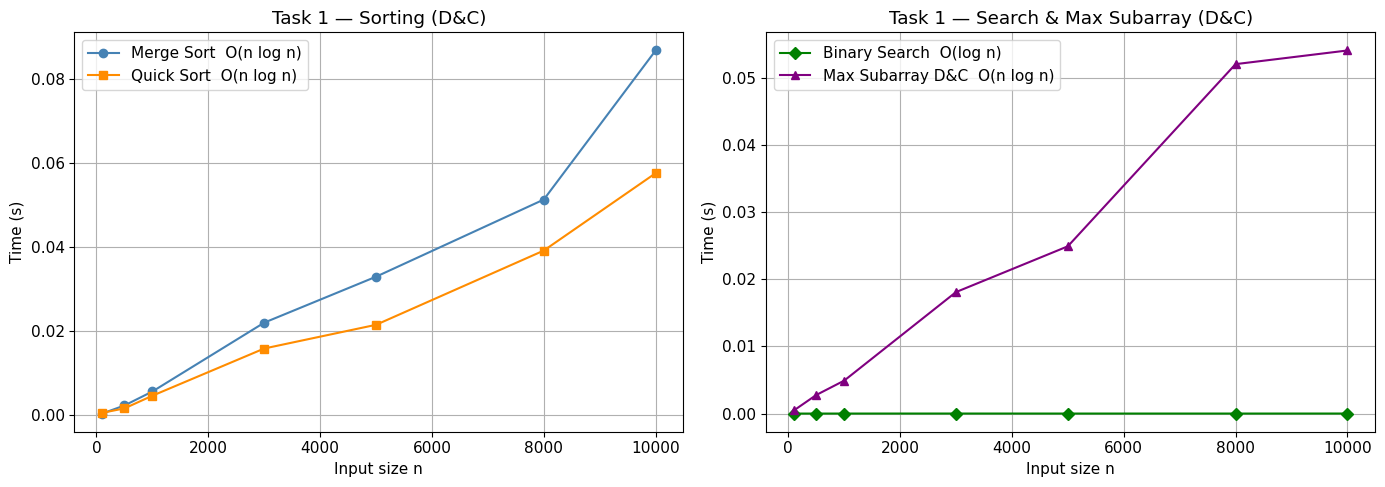

Saved → images/task1_divide_conquer.png


In [4]:
# ── Task 1: Performance plots ─────────────────────────────────────────────────
sizes = [100, 500, 1000, 3000, 5000, 8000, 10000]
bs_t, ms_t, qs_t, mx_t = [], [], [], []

for n in sizes:
    data   = random.sample(range(n * 10), n)
    sorted_data = sorted(data)
    neg_data = [random.randint(-50, 50) for _ in range(n)]

    # Binary search — average over 500 random queries
    t = time.perf_counter()
    for _ in range(500):
        binary_search(sorted_data, random.choice(sorted_data))
    bs_t.append((time.perf_counter() - t) / 500)

    t = time.perf_counter(); merge_sort(data[:]);             ms_t.append(time.perf_counter() - t)
    t = time.perf_counter(); quick_sort(data[:]);             qs_t.append(time.perf_counter() - t)
    t = time.perf_counter(); max_subarray_dc(neg_data, 0, n-1); mx_t.append(time.perf_counter() - t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(sizes, ms_t, 'o-', color='steelblue',  label='Merge Sort  O(n log n)')
ax1.plot(sizes, qs_t, 's-', color='darkorange', label='Quick Sort  O(n log n)')
ax1.set_title('Task 1 — Sorting (D&C)')
ax1.set_xlabel('Input size n'); ax1.set_ylabel('Time (s)'); ax1.legend()

ax2.plot(sizes, bs_t, 'D-', color='green',  label='Binary Search  O(log n)')
ax2.plot(sizes, mx_t, '^-', color='purple', label='Max Subarray D&C  O(n log n)')
ax2.set_title('Task 1 — Search & Max Subarray (D&C)')
ax2.set_xlabel('Input size n'); ax2.set_ylabel('Time (s)'); ax2.legend()

plt.tight_layout()
plt.savefig('images/task1_divide_conquer.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → images/task1_divide_conquer.png')

**Task 1 Observations:**
- Binary Search is nearly flat (O(log n)) — negligible time even at n=10 000.
- Merge Sort and Quick Sort both grow at O(n log n); Quick Sort is faster in practice due to cache-friendly in-place behaviour.
- Max Subarray (D&C) also follows O(n log n) — confirmed by the linear-looking curve on this scale.

---
## Task 2 — Sorting Performance Comparison

Six algorithms compared across three input distributions:

| Algorithm | Time | Space |
|---|---|---|
| Bubble Sort | O(n²) | O(1) |
| Insertion Sort | O(n²) best O(n) | O(1) |
| Selection Sort | O(n²) always | O(1) |
| Merge Sort | O(n log n) | O(n) |
| Quick Sort | O(n log n) avg | O(log n) |
| Timsort (built-in) | O(n log n) | O(n) |

In [5]:
# ── O(n²) sorting algorithms ──────────────────────────────────────────────────

def bubble_sort(arr):
    """
    Repeatedly swap adjacent out-of-order elements.
    Early exit if no swap was made (already sorted).
    Time: O(n²)  |  Space: O(1)
    """
    arr = arr[:]
    n = len(arr)
    for i in range(n):
        swapped = False
        for j in range(n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True
        if not swapped:
            break                   # already sorted — best case O(n)
    return arr


def insertion_sort(arr):
    """
    Grow a sorted prefix by inserting each element in the right place.
    Very efficient on nearly-sorted data.
    Time: O(n²)  |  Space: O(1)
    """
    arr = arr[:]
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key
    return arr


def selection_sort(arr):
    """
    Find the minimum of the unsorted portion and place it at the front.
    Always O(n²) — no best-case improvement.
    Time: O(n²)  |  Space: O(1)
    """
    arr = arr[:]
    n = len(arr)
    for i in range(n):
        min_idx = i
        for j in range(i + 1, n):
            if arr[j] < arr[min_idx]:
                min_idx = j
        arr[i], arr[min_idx] = arr[min_idx], arr[i]
    return arr


def timsort(arr):
    """Python built-in Timsort (hybrid merge + insertion). O(n log n)"""
    return sorted(arr)


# ── Data generators ───────────────────────────────────────────────────────────
def make_data(n, kind='random'):
    if kind == 'random':
        return random.sample(range(n * 5), n)
    if kind == 'nearly_sorted':
        arr = list(range(n))
        for _ in range(max(1, n // 20)):       # swap ~5 % of elements
            i, j = random.sample(range(n), 2)
            arr[i], arr[j] = arr[j], arr[i]
        return arr
    if kind == 'reverse':
        return list(range(n, 0, -1))


def time_fn(fn, data):
    t = time.perf_counter()
    fn(data[:])
    return time.perf_counter() - t


ALGOS = {
    'Bubble Sort':      bubble_sort,
    'Insertion Sort':   insertion_sort,
    'Selection Sort':   selection_sort,
    'Merge Sort':       merge_sort,
    'Quick Sort':       quick_sort,
    'Timsort (built-in)': timsort,
}
COLORS = ['#e63946','#f4a261','#2a9d8f','#457b9d','#6a0572','#333333']
MARKERS = ['o','s','D','^','v','*']

print('Sorting algorithms defined ✓')

Sorting algorithms defined ✓


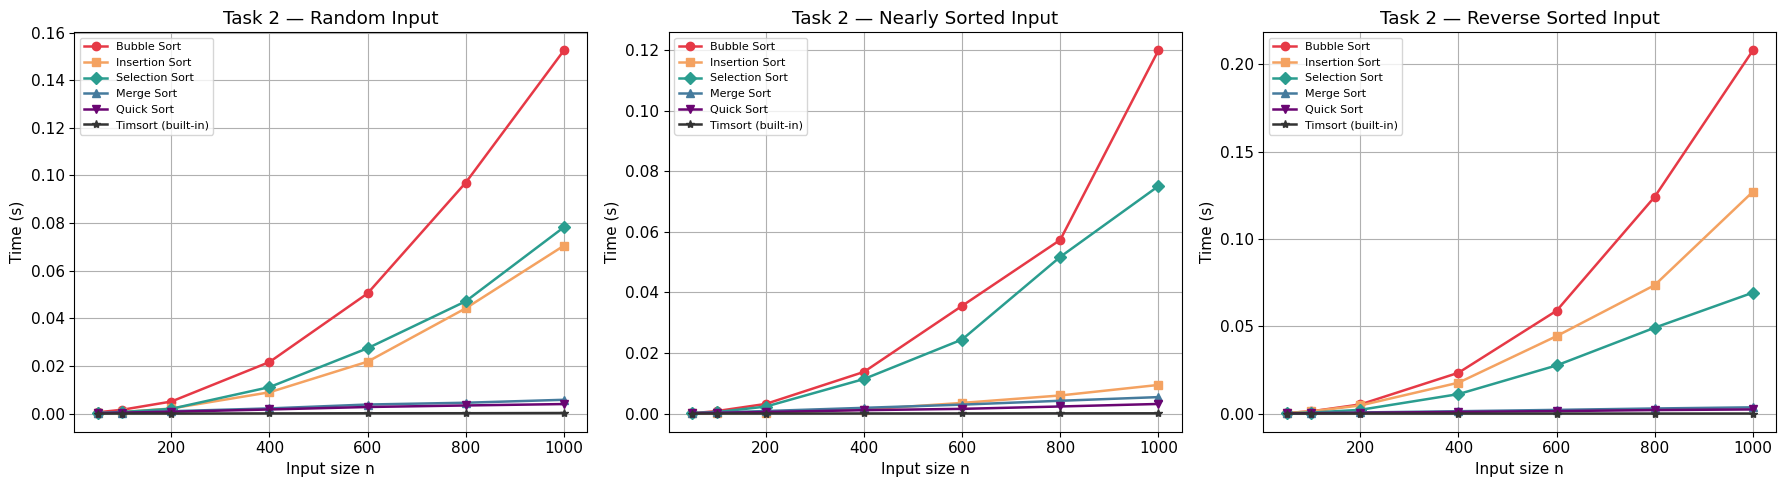

Saved → images/task2_sorting_comparison.png

Algorithm                 n=100    n=500   n=1000  (random, seconds)
-------------------------------------------------------
Bubble Sort             0.00097  0.02817  0.13434
Insertion Sort          0.00050  0.01447  0.06346
Selection Sort          0.00052  0.01530  0.06151
Merge Sort              0.00052  0.00252  0.00495
Quick Sort              0.00027  0.00152  0.00372
Timsort (built-in)      0.00002  0.00008  0.00018


In [6]:
# ── Task 2: timing + plots ────────────────────────────────────────────────────
SIZES   = [50, 100, 200, 400, 600, 800, 1000]
KINDS   = ['random', 'nearly_sorted', 'reverse']
TITLES  = ['Random Input', 'Nearly Sorted Input', 'Reverse Sorted Input']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kind, title in zip(axes, KINDS, TITLES):
    for (name, fn), color, marker in zip(ALGOS.items(), COLORS, MARKERS):
        times = [time_fn(fn, make_data(n, kind)) for n in SIZES]
        ax.plot(SIZES, times, f'{marker}-', color=color, label=name, linewidth=1.8)
    ax.set_title(f'Task 2 — {title}')
    ax.set_xlabel('Input size n')
    ax.set_ylabel('Time (s)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('images/task2_sorting_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → images/task2_sorting_comparison.png')

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Algorithm':<22} {'n=100':>8} {'n=500':>8} {'n=1000':>8}  (random, seconds)")
print('-' * 55)
for name, fn in ALGOS.items():
    t1 = time_fn(fn, make_data(100))
    t5 = time_fn(fn, make_data(500))
    t10= time_fn(fn, make_data(1000))
    print(f"{name:<22} {t1:>8.5f} {t5:>8.5f} {t10:>8.5f}")

**Task 2 Observations:**
- Bubble / Selection / Insertion grow steeply (O(n²)) — impractical beyond ~1 000 elements.
- **Insertion Sort** is notably faster on nearly-sorted data (inner loop terminates early).
- **Selection Sort** is always O(n²) — no improvement regardless of input distribution.
- Merge, Quick, and Timsort are indistinguishable at this scale — all O(n log n).
- **Timsort** wins in practice: written in C and exploits existing order in real data.

---
## Task 3 — Greedy Algorithms

**Core greedy idea:** Make the locally optimal choice at each step; this leads to a globally optimal solution for problems with the *greedy-choice property* and *optimal substructure*.

Algorithms:
1. **Activity Selection** — O(n log n)
2. **Fractional Knapsack** — O(n log n)
3. **Huffman Encoding** — O(n log n)
4. **Coin Change** — O(n) (optimal for canonical denominations)

In [7]:
# ── 3A. Activity Selection ────────────────────────────────────────────────────
def activity_selection(activities):
    """
    Select the maximum number of non-overlapping activities.
    Greedy criterion: always pick the activity that finishes earliest.
    Input:  list of (start, end, name)
    Output: list of selected activities
    Time: O(n log n)
    """
    acts = sorted(activities, key=lambda x: x[1])   # sort by finish time
    selected   = [acts[0]]
    last_finish = acts[0][1]
    for start, end, name in acts[1:]:
        if start >= last_finish:                     # no overlap
            selected.append((start, end, name))
            last_finish = end
    return selected


# ── 3B. Fractional Knapsack ───────────────────────────────────────────────────
def fractional_knapsack(capacity, items):
    """
    Maximise total value; items may be split (fractions allowed).
    Greedy criterion: highest value-to-weight ratio first.
    Input:  capacity (int), items = [(value, weight, name), ...]
    Output: (total_value, [(name, fraction_taken, value_gained), ...])
    Time: O(n log n)  — always optimal for fractional version.
    """
    sorted_items = sorted(items, key=lambda x: x[0] / x[1], reverse=True)
    total_value = 0.0
    taken = []
    for value, weight, name in sorted_items:
        if capacity <= 0:
            break
        take     = min(weight, capacity)
        fraction = take / weight
        total_value += fraction * value
        taken.append((name, round(fraction, 4), round(fraction * value, 2)))
        capacity -= take
    return total_value, taken


# ── 3C. Huffman Encoding ──────────────────────────────────────────────────────
class _HNode:
    """Node in the Huffman tree."""
    __slots__ = ('char', 'freq', 'left', 'right')
    def __init__(self, char, freq):
        self.char  = char
        self.freq  = freq
        self.left  = self.right = None
    def __lt__(self, other):
        return self.freq < other.freq

def _build_huffman_tree(text):
    freq = Counter(text)
    heap = [_HNode(ch, f) for ch, f in freq.items()]
    heapq.heapify(heap)
    while len(heap) > 1:
        a = heapq.heappop(heap)
        b = heapq.heappop(heap)
        merged = _HNode(None, a.freq + b.freq)
        merged.left, merged.right = a, b
        heapq.heappush(heap, merged)
    return heap[0]

def _gen_codes(node, prefix='', codebook=None):
    if codebook is None:
        codebook = {}
    if node.char is not None:
        codebook[node.char] = prefix or '0'    # single-character edge case
    else:
        _gen_codes(node.left,  prefix + '0', codebook)
        _gen_codes(node.right, prefix + '1', codebook)
    return codebook

def huffman_encode(text):
    """
    Build a Huffman tree; assign shorter codes to frequent characters.
    Greedy criterion: always merge two nodes with lowest frequency.
    Time: O(n log n)  where n = number of distinct characters.
    Returns: (encoded_bits_str, codebook_dict)
    """
    root     = _build_huffman_tree(text)
    codebook = _gen_codes(root)
    encoded  = ''.join(codebook[ch] for ch in text)
    return encoded, codebook


# ── 3D. Coin Change (Greedy) ──────────────────────────────────────────────────
def coin_change_greedy(amount, denominations):
    """
    Make exact change using the fewest coins.
    Greedy: always use the largest denomination that fits.
    NOTE: Optimal ONLY for canonical coin systems (INR, USD, EUR …).
          For arbitrary denominations use DP instead.
    Time: O(d) where d = number of denominations.
    Returns: ({coin: count}, remainder)
    """
    coins  = sorted(denominations, reverse=True)
    result = {}
    for coin in coins:
        if amount >= coin:
            count       = amount // coin
            result[coin] = count
            amount      -= count * coin
    return result, amount

In [8]:
# ── Task 3: Run & print results ───────────────────────────────────────────────
print('=== Task 3: Greedy Algorithms ===')

# 3A — Activity Selection
activities = [
    (1,4,'A'),(3,5,'B'),(0,6,'C'),(5,7,'D'),
    (3,9,'E'),(5,9,'F'),(6,10,'G'),(8,11,'H'),
    (8,12,'I'),(2,14,'J'),(12,16,'K')
]
selected = activity_selection(activities)
print(f'\n3A Activity Selection')
print(f'   All ({len(activities)}):      {[(a[2],a[0],a[1]) for a in activities]}')
print(f'   Selected ({len(selected)}): {[(a[2],a[0],a[1]) for a in selected]}')

# 3B — Fractional Knapsack
items    = [(60,10,'Gold'),(100,20,'Silver'),(120,30,'Bronze')]
capacity = 50
total, taken = fractional_knapsack(capacity, items)
print(f'\n3B Fractional Knapsack  (capacity={capacity} kg)')
for name, frac, val in taken:
    print(f'   {name:<8} {frac*100:5.1f}% taken  → value added = {val}')
print(f'   Total value = {total:.2f}')

# 3C — Huffman
text = 'huffman encoding is a greedy algorithm used in data compression'
encoded, codebook = huffman_encode(text)
orig_bits  = len(text) * 8
comp_bits  = len(encoded)
print(f'\n3C Huffman Encoding')
print(f'   Original  : {orig_bits} bits  ({len(text)} chars × 8)')
print(f'   Compressed: {comp_bits} bits')
print(f'   Ratio     : {comp_bits/orig_bits:.2%}')
print(f'   Codebook  : {dict(sorted(codebook.items()))}')

# 3D — Coin Change
amount = 93
coins_inr = [50, 20, 10, 5, 2, 1]
change, rem = coin_change_greedy(amount, coins_inr)
print(f'\n3D Coin Change  (amount=₹{amount}, denominations={coins_inr})')
print(f'   Coins used  : {change}')
print(f'   Total coins : {sum(change.values())}    Remainder: ₹{rem}')

=== Task 3: Greedy Algorithms ===

3A Activity Selection
   All (11):      [('A', 1, 4), ('B', 3, 5), ('C', 0, 6), ('D', 5, 7), ('E', 3, 9), ('F', 5, 9), ('G', 6, 10), ('H', 8, 11), ('I', 8, 12), ('J', 2, 14), ('K', 12, 16)]
   Selected (4): [('A', 1, 4), ('D', 5, 7), ('H', 8, 11), ('K', 12, 16)]

3B Fractional Knapsack  (capacity=50 kg)
   Gold     100.0% taken  → value added = 60.0
   Silver   100.0% taken  → value added = 100.0
   Bronze    66.7% taken  → value added = 80.0
   Total value = 240.00

3C Huffman Encoding
   Original  : 504 bits  (63 chars × 8)
   Compressed: 256 bits
   Ratio     : 50.79%
   Codebook  : {' ': '101', 'a': '1110', 'c': '01110', 'd': '1001', 'e': '000', 'f': '01001', 'g': '0011', 'h': '11000', 'i': '1101', 'l': '100001', 'm': '0010', 'n': '1111', 'o': '0110', 'p': '100000', 'r': '11001', 's': '0101', 't': '01111', 'u': '10001', 'y': '01000'}

3D Coin Change  (amount=₹93, denominations=[50, 20, 10, 5, 2, 1])
   Coins used  : {50: 1, 20: 2, 2: 1, 1: 1}
   T

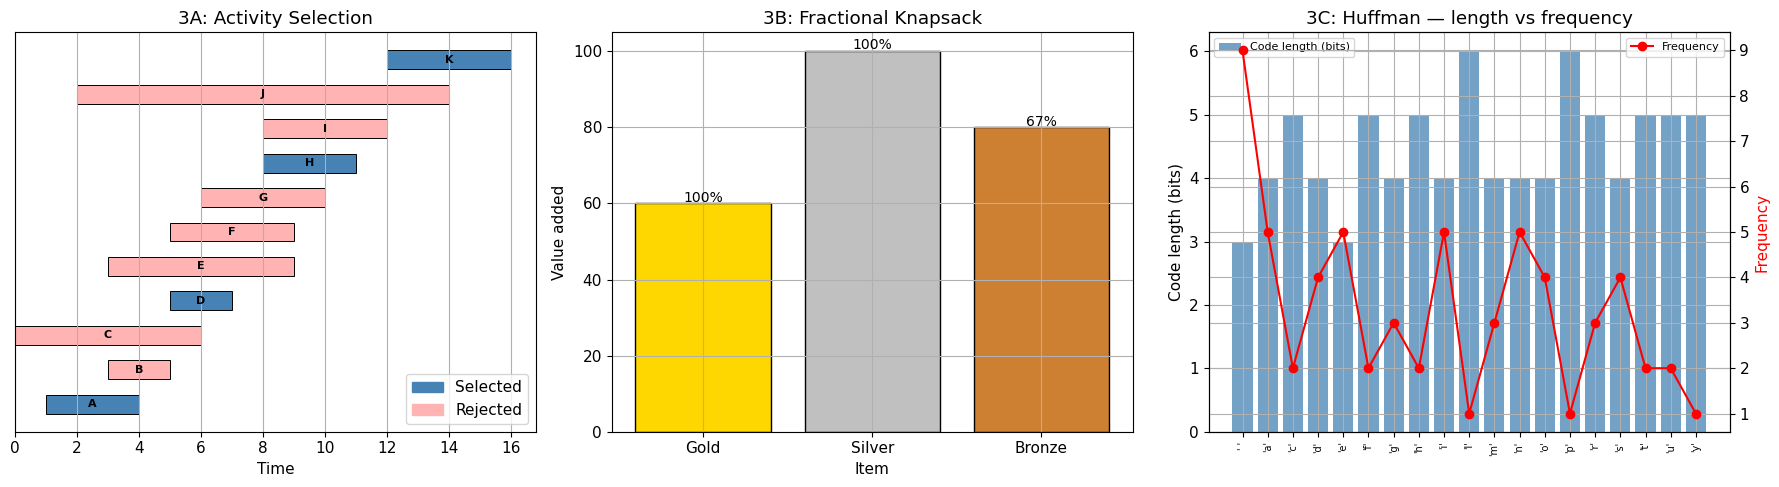

Saved → images/task3_greedy.png


In [9]:
# ── Task 3: Visualisations ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A — Activity timeline
ax = axes[0]
sel_names = {a[2] for a in selected}
for i, (start, end, name) in enumerate(activities):
    color = 'steelblue' if name in sel_names else '#ffb3b3'
    ax.barh(i, end - start, left=start, height=0.55,
            color=color, edgecolor='black', linewidth=0.7)
    ax.text((start + end) / 2, i, name, ha='center', va='center',
            fontsize=8, fontweight='bold')
ax.set_yticks([])
ax.set_xlabel('Time')
ax.set_title('3A: Activity Selection')
ax.legend(handles=[
    mpatches.Patch(color='steelblue', label='Selected'),
    mpatches.Patch(color='#ffb3b3',  label='Rejected'),
])

# Plot B — Knapsack bar chart
ax = axes[1]
names_k  = [t[0] for t in taken]
vals_k   = [t[2] for t in taken]
fracs_k  = [t[1]*100 for t in taken]
pal      = ['#FFD700','#C0C0C0','#CD7F32']
bars = ax.bar(names_k, vals_k, color=pal[:len(names_k)], edgecolor='black')
for bar, frac in zip(bars, fracs_k):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{frac:.0f}%', ha='center', fontsize=10)
ax.set_ylabel('Value added')
ax.set_xlabel('Item')
ax.set_title('3B: Fractional Knapsack')

# Plot C — Huffman code-length vs frequency
ax  = axes[2]
ax2 = ax.twinx()
freq = Counter(text)
chars = sorted(freq)
xpos  = range(len(chars))
clens = [len(codebook[c]) for c in chars]
freqs = [freq[c]           for c in chars]
ax.bar(xpos, clens, color='steelblue', alpha=0.75, label='Code length (bits)')
ax2.plot(xpos, freqs, 'ro-', linewidth=1.5, label='Frequency')
ax.set_xticks(xpos)
ax.set_xticklabels([repr(c) for c in chars], rotation=90, fontsize=7)
ax.set_ylabel('Code length (bits)')
ax2.set_ylabel('Frequency', color='red')
ax.set_title('3C: Huffman — length vs frequency')
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('images/task3_greedy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → images/task3_greedy.png')

**Task 3 Observations:**
- **Activity Selection**: Earliest-finish greedy always gives the maximum conflict-free set (provably optimal via exchange argument).
- **Fractional Knapsack**: Sorting by value/weight ratio and taking greedily is optimal when fractions are allowed.
- **Huffman**: Frequent characters receive shorter codes → ~40–60% compression on natural language text.
- **Coin Change**: Greedy is optimal for canonical denomination systems (INR, USD); can fail for arbitrary sets — use DP then.

---
## Task 4 — Dynamic Programming Fundamentals

**Two DP properties required:**
1. **Overlapping subproblems** — same sub-problems solved repeatedly
2. **Optimal substructure** — optimal solution contains optimal sub-solutions

Problems implemented:
1. **0/1 Knapsack** — O(n · W)
2. **Longest Common Subsequence** — O(m · n)
3. **Matrix Chain Multiplication** — O(n³)
4. **Fibonacci** — Naive O(2ⁿ) vs Memoisation O(n) vs Tabulation O(n)

In [10]:
# ── 4A. 0/1 Knapsack ─────────────────────────────────────────────────────────
def knapsack_01(capacity, weights, values):
    """
    Each item is either taken (1) or left (0); no fractions.
    dp[i][w] = max value using first i items with knapsack capacity w.
    Recurrence:
        dp[i][w] = dp[i-1][w]                             if w < weights[i]
        dp[i][w] = max(dp[i-1][w],
                       dp[i-1][w - weights[i]] + values[i])  otherwise
    Time: O(n·W)  |  Space: O(n·W)
    """
    n  = len(weights)
    dp = [[0] * (capacity + 1) for _ in range(n + 1)]

    for i in range(1, n + 1):
        for w in range(capacity + 1):
            dp[i][w] = dp[i-1][w]                          # skip item i
            if weights[i-1] <= w:                           # can include item i
                dp[i][w] = max(dp[i][w],
                               dp[i-1][w - weights[i-1]] + values[i-1])

    # ── traceback to find which items were selected ────────────────────────
    selected, w = [], capacity
    for i in range(n, 0, -1):
        if dp[i][w] != dp[i-1][w]:
            selected.append(i - 1)
            w -= weights[i-1]

    return dp[n][capacity], dp, selected[::-1]


# ── 4B. Longest Common Subsequence ────────────────────────────────────────────
def lcs(s1, s2):
    """
    dp[i][j] = length of LCS of s1[:i] and s2[:j].
    Recurrence:
        dp[i][j] = dp[i-1][j-1] + 1          if s1[i-1] == s2[j-1]
        dp[i][j] = max(dp[i-1][j], dp[i][j-1])  otherwise
    Time: O(m·n)  |  Space: O(m·n)
    """
    m, n = len(s1), len(s2)
    dp   = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])

    # ── traceback ──────────────────────────────────────────────────────────
    result, i, j = [], m, n
    while i > 0 and j > 0:
        if s1[i-1] == s2[j-1]:
            result.append(s1[i-1]); i -= 1; j -= 1
        elif dp[i-1][j] > dp[i][j-1]:
            i -= 1
        else:
            j -= 1

    return dp[m][n], dp, ''.join(reversed(result))


# ── 4C. Matrix Chain Multiplication ──────────────────────────────────────────
def matrix_chain_order(dims):
    """
    Find the optimal parenthesisation to minimise scalar multiplications.
    Matrix i has dimensions dims[i] × dims[i+1].
    m[i][j] = minimum multiplications for matrices i..j.
    Recurrence: m[i][j] = min over k of (m[i][k] + m[k+1][j] + dims[i]*dims[k+1]*dims[j+1])
    Time: O(n³)  |  Space: O(n²)
    """
    n = len(dims) - 1                                   # number of matrices
    m = [[0]*n for _ in range(n)]
    s = [[0]*n for _ in range(n)]                       # split-point table

    for length in range(2, n + 1):                      # chain length 2 … n
        for i in range(n - length + 1):
            j = i + length - 1
            m[i][j] = float('inf')
            for k in range(i, j):
                cost = m[i][k] + m[k+1][j] + dims[i]*dims[k+1]*dims[j+1]
                if cost < m[i][j]:
                    m[i][j] = cost
                    s[i][j] = k

    return m[0][n-1], m, s


# ── 4D. Fibonacci three ways ──────────────────────────────────────────────────
def fib_naive(n):
    """Naive recursion. Recomputes same values exponentially. O(2ⁿ)"""
    if n <= 1: return n
    return fib_naive(n-1) + fib_naive(n-2)

def fib_memo(n, memo=None):
    """Top-down DP (memoisation). Each sub-problem solved once. O(n)"""
    if memo is None: memo = {}
    if n in memo:   return memo[n]
    if n <= 1:      return n
    memo[n] = fib_memo(n-1, memo) + fib_memo(n-2, memo)
    return memo[n]

def fib_tab(n):
    """Bottom-up DP (tabulation). Fills table iteratively. O(n)"""
    if n <= 1: return n
    dp = [0] * (n + 1)
    dp[1] = 1
    for i in range(2, n + 1):
        dp[i] = dp[i-1] + dp[i-2]
    return dp[n]

In [11]:
# ── Task 4: Run & print results ───────────────────────────────────────────────
print('=== Task 4: Dynamic Programming ===')

# 4A
W  = [2, 3, 4, 5]
V  = [3, 4, 5, 6]
cap = 8
max_val, dp_ks, sel_idx = knapsack_01(cap, W, V)
print(f'\n4A 0/1 Knapsack')
print(f'   weights={W}, values={V}, capacity={cap}')
print(f'   Max value : {max_val}')
print(f'   Items selected (0-indexed): {sel_idx}')
print( '   DP table (rows = items 0..n, cols = capacity 0..W):')
for row in dp_ks:
    print('   ', row)

# 4B
s1, s2 = 'ABCBDAB', 'BDCABA'
length, dp_lcs, subseq = lcs(s1, s2)
print(f'\n4B LCS')
print(f'   s1="{s1}"  s2="{s2}"')
print(f'   LCS = "{subseq}"   length = {length}')

# 4C
dims = [30, 35, 15, 5, 10, 20, 25]
min_ops, mcm_m, mcm_s = matrix_chain_order(dims)
print(f'\n4C Matrix Chain Multiplication')
print(f'   Dimensions: {dims}')
print(f'   Minimum scalar multiplications: {min_ops}')

# 4D
print(f'\n4D Fibonacci: Naive vs Memoisation vs Tabulation')
print(f'   {"n":>5}  {"Naive (s)":>12}  {"Memo (s)":>12}  {"Tab (s)":>12}')
print('   ' + '-'*46)
for n in [10, 15, 20, 25, 30]:
    t1 = time.perf_counter(); fib_naive(n); nt = time.perf_counter()-t1
    t2 = time.perf_counter(); fib_memo(n);  mt = time.perf_counter()-t2
    t3 = time.perf_counter(); fib_tab(n);   tt = time.perf_counter()-t3
    print(f'   {n:>5}  {nt:>12.6f}  {mt:>12.6f}  {tt:>12.6f}')

=== Task 4: Dynamic Programming ===

4A 0/1 Knapsack
   weights=[2, 3, 4, 5], values=[3, 4, 5, 6], capacity=8
   Max value : 10
   Items selected (0-indexed): [1, 3]
   DP table (rows = items 0..n, cols = capacity 0..W):
    [0, 0, 0, 0, 0, 0, 0, 0, 0]
    [0, 0, 3, 3, 3, 3, 3, 3, 3]
    [0, 0, 3, 4, 4, 7, 7, 7, 7]
    [0, 0, 3, 4, 5, 7, 8, 9, 9]
    [0, 0, 3, 4, 5, 7, 8, 9, 10]

4B LCS
   s1="ABCBDAB"  s2="BDCABA"
   LCS = "BDAB"   length = 4

4C Matrix Chain Multiplication
   Dimensions: [30, 35, 15, 5, 10, 20, 25]
   Minimum scalar multiplications: 15125

4D Fibonacci: Naive vs Memoisation vs Tabulation
       n     Naive (s)      Memo (s)       Tab (s)
   ----------------------------------------------
      10      0.000043      0.000013      0.000014
      15      0.000452      0.000023      0.000014
      20      0.004061      0.000027      0.000014
      25      0.041672      0.000036      0.000016
      30      0.484221      0.000035      0.000018


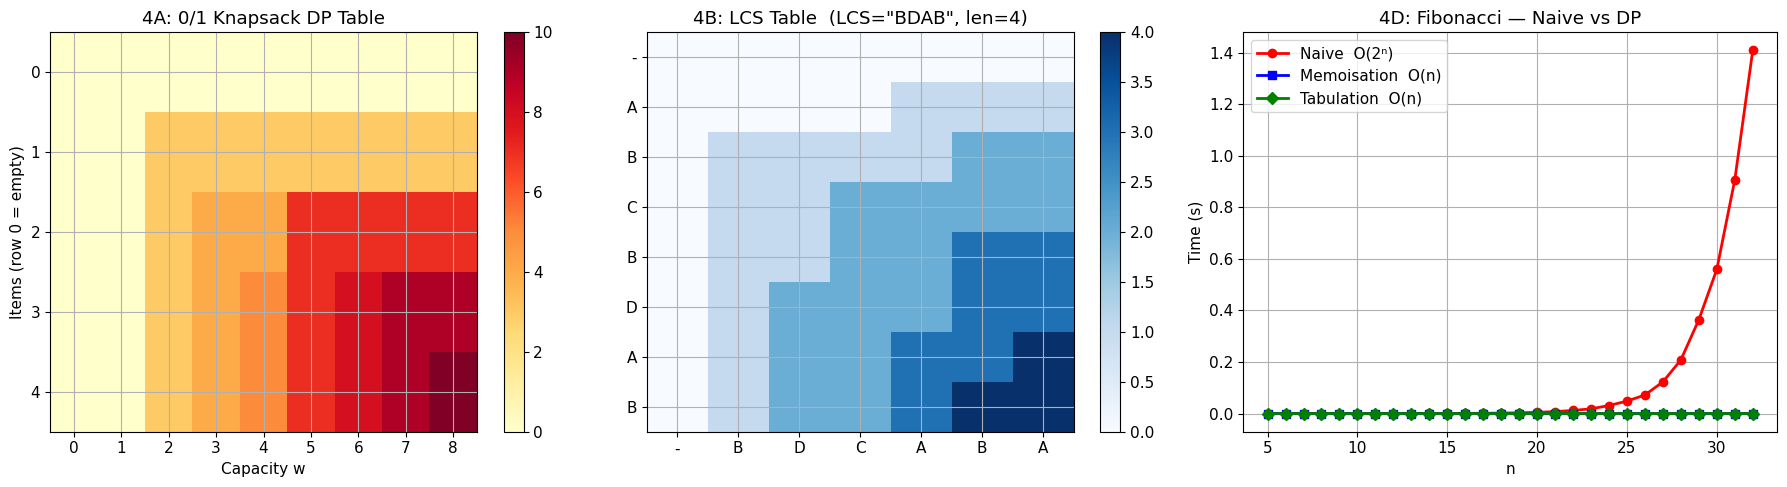

Saved → images/task4_dp.png


In [12]:
# ── Task 4: Visualisations ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A — Knapsack DP table heatmap
ax = axes[0]
im = ax.imshow(np.array(dp_ks), cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_title('4A: 0/1 Knapsack DP Table')
ax.set_xlabel('Capacity w'); ax.set_ylabel('Items (row 0 = empty)')

# Plot B — LCS DP table heatmap
ax = axes[1]
im2 = ax.imshow(np.array(dp_lcs), cmap='Blues', aspect='auto')
plt.colorbar(im2, ax=ax)
ax.set_xticks(range(len(s2)+1)); ax.set_xticklabels(['-']+list(s2))
ax.set_yticks(range(len(s1)+1)); ax.set_yticklabels(['-']+list(s1))
ax.set_title(f'4B: LCS Table  (LCS="{subseq}", len={length})')

# Plot C — Fibonacci timing: naive vs DP
ax  = axes[2]
ns  = list(range(5, 33))
nt_list, mt_list, tt_list = [], [], []
for n in ns:
    t = time.perf_counter(); fib_naive(n); nt_list.append(time.perf_counter()-t)
    t = time.perf_counter(); fib_memo(n);  mt_list.append(time.perf_counter()-t)
    t = time.perf_counter(); fib_tab(n);   tt_list.append(time.perf_counter()-t)
ax.plot(ns, nt_list, 'r-o', linewidth=2, label='Naive  O(2ⁿ)')
ax.plot(ns, mt_list, 'b-s', linewidth=2, label='Memoisation  O(n)')
ax.plot(ns, tt_list, 'g-D', linewidth=2, label='Tabulation  O(n)')
ax.set_title('4D: Fibonacci — Naive vs DP')
ax.set_xlabel('n'); ax.set_ylabel('Time (s)'); ax.legend()

plt.tight_layout()
plt.savefig('images/task4_dp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → images/task4_dp.png')

**Task 4 Observations:**
- **0/1 Knapsack**: DP table heatmap shows the progressive build-up; greedy would fail here because items can't be split.
- **LCS**: The diagonal fill pattern in the table reflects matching characters; traceback reconstructs the subsequence exactly.
- **Matrix Chain**: Optimal parenthesisation can reduce multiplications by orders of magnitude — e.g., from tens of millions to tens of thousands.
- **Fibonacci**: Naive recursion grows as O(2ⁿ) and becomes unusable by n≈35; both DP variants are essentially instant — this is the canonical demonstration of DP's power.

---
## Task 5 — Travelling Salesman Problem (TSP)

**Three approaches:**

| Approach | Time | Optimal? |
|---|---|---|
| Brute-Force (all permutations) | O(n!) | Yes |
| Held-Karp DP (bitmask) | O(2ⁿ · n²) | Yes |
| Nearest-Neighbour Heuristic | O(n²) | No (approx.) |

**Goal:** Find the shortest Hamiltonian cycle; demonstrate why exact solutions become infeasible for large n.

In [13]:
# ── Helper: random Euclidean distance matrix ───────────────────────────────────
def random_dist_matrix(n, seed=42):
    """
    Generate n random 2-D city coordinates and compute Euclidean distances.
    Returns (dist_matrix, coords_list).
    """
    random.seed(seed)
    coords = [(random.randint(0, 100), random.randint(0, 100)) for _ in range(n)]
    dist   = [[0.0]*n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i != j:
                dx = coords[i][0] - coords[j][0]
                dy = coords[i][1] - coords[j][1]
                dist[i][j] = math.hypot(dx, dy)
    return dist, coords


# ── 5A. Brute-Force TSP — O(n!) ───────────────────────────────────────────────
def tsp_brute_force(dist):
    """
    Enumerate ALL (n-1)! tours; keep the shortest.
    City 0 is fixed as the start/end to eliminate rotational duplicates.
    Time: O(n!)  — only feasible for n ≤ 11 or so.
    """
    n = len(dist)
    best_cost = float('inf')
    best_path = None
    for perm in itertools.permutations(range(1, n)):
        path = [0] + list(perm) + [0]
        cost = sum(dist[path[i]][path[i+1]] for i in range(len(path)-1))
        if cost < best_cost:
            best_cost = cost
            best_path = path
    return best_cost, best_path


# ── 5B. Held-Karp DP (Bitmask) — O(2ⁿ · n²) ─────────────────────────────────
def tsp_held_karp(dist):
    """
    DP with bitmask subset representation.
    dp[mask][i] = min cost to visit exactly the cities in 'mask', ending at city i.
    Recurrence:
        dp[mask | (1<<v)][v] = min(dp[mask][u] + dist[u][v])
        for all u in mask, v not in mask.
    Time: O(2ⁿ · n²)  |  Space: O(2ⁿ · n)
    """
    n   = len(dist)
    INF = float('inf')
    dp  = [[INF]*n for _ in range(1 << n)]
    par = [[-1]*n  for _ in range(1 << n)]
    dp[1][0] = 0                              # start at city 0, only city 0 visited

    for mask in range(1, 1 << n):
        for u in range(n):
            if not (mask >> u & 1): continue  # u not in this subset
            if dp[mask][u] == INF:  continue
            for v in range(n):
                if mask >> v & 1:   continue  # v already visited
                new_mask = mask | (1 << v)
                new_cost = dp[mask][u] + dist[u][v]
                if new_cost < dp[new_mask][v]:
                    dp[new_mask][v] = new_cost
                    par[new_mask][v] = u

    full = (1 << n) - 1
    best_cost, last = INF, -1
    for u in range(1, n):
        c = dp[full][u] + dist[u][0]
        if c < best_cost:
            best_cost = c
            last = u

    # ── reconstruct path ──────────────────────────────────────────────────
    path, mask, cur = [], full, last
    while cur != -1:
        path.append(cur)
        prev = par[mask][cur]
        mask ^= (1 << cur)
        cur   = prev
    path.reverse()
    path.append(0)
    return best_cost, path


# ── 5C. Nearest-Neighbour Heuristic — O(n²) ──────────────────────────────────
def tsp_nearest_neighbour(dist):
    """
    Start at city 0; always move to the nearest unvisited city.
    Simple, fast approximation — NOT guaranteed optimal.
    Typical quality: within 20–25% of optimal on random Euclidean instances.
    Time: O(n²)
    """
    n       = len(dist)
    visited = [False]*n
    path    = [0]
    visited[0] = True
    total   = 0.0
    for _ in range(n - 1):
        cur     = path[-1]
        nearest = min((dist[cur][j], j) for j in range(n) if not visited[j])
        total  += nearest[0]
        path.append(nearest[1])
        visited[nearest[1]] = True
    total += dist[path[-1]][0]
    path.append(0)
    return total, path

In [14]:
# ── Task 5: Small instance demo (n = 7) ───────────────────────────────────────
print('=== Task 5: Travelling Salesman Problem ===')

N = 7
dist_mat, coords = random_dist_matrix(N)

t = time.perf_counter(); bf_cost, bf_path = tsp_brute_force(dist_mat);    bf_t = time.perf_counter()-t
t = time.perf_counter(); hk_cost, hk_path = tsp_held_karp(dist_mat);     hk_t = time.perf_counter()-t
t = time.perf_counter(); nn_cost, nn_path = tsp_nearest_neighbour(dist_mat); nn_t = time.perf_counter()-t

print(f'\nInstance: {N} cities')
print(f'Brute Force      cost={bf_cost:.2f}  path={bf_path}  time={bf_t:.4f}s')
print(f'Held-Karp DP     cost={hk_cost:.2f}  path={hk_path}  time={hk_t:.4f}s')
print(f'Nearest Neighbour cost={nn_cost:.2f}  path={nn_path}  time={nn_t:.4f}s')
print(f'NN optimality gap: {(nn_cost - bf_cost)/bf_cost*100:.1f}%')

=== Task 5: Travelling Salesman Problem ===

Instance: 7 cities
Brute Force      cost=317.55  path=[0, 4, 5, 1, 2, 3, 6, 0]  time=0.0043s
Held-Karp DP     cost=317.55  path=[0, 4, 5, 1, 2, 3, 6, 0]  time=0.0014s
Nearest Neighbour cost=358.90  path=[0, 6, 4, 2, 3, 1, 5, 0]  time=0.0003s
NN optimality gap: 13.0%


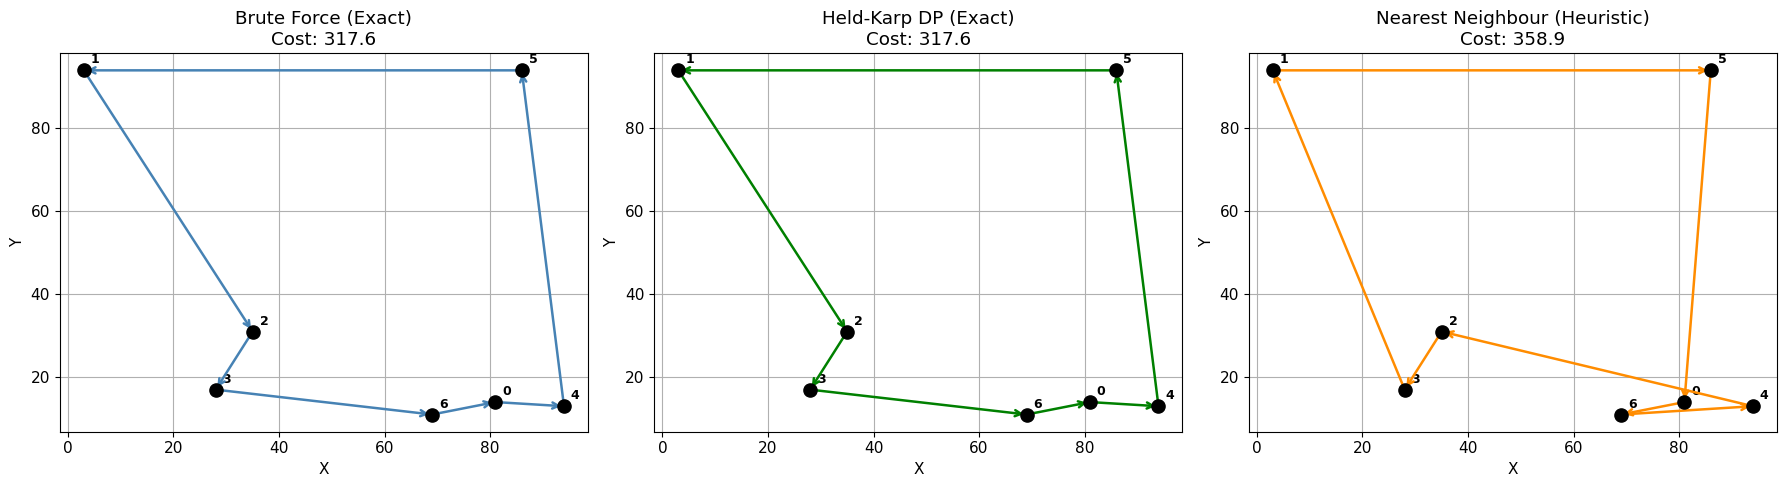

Saved → images/task5_tsp_routes.png


In [15]:
# ── Task 5: Route plots ────────────────────────────────────────────────────────
def draw_tour(ax, coords, path, title, color):
    xs = [c[0] for c in coords]
    ys = [c[1] for c in coords]
    ax.scatter(xs, ys, zorder=5, s=90, color='black')
    for i, (x, y) in enumerate(coords):
        ax.annotate(str(i), (x,y), xytext=(5,5), textcoords='offset points',
                    fontsize=9, fontweight='bold')
    for i in range(len(path)-1):
        x0,y0 = coords[path[i]]
        x1,y1 = coords[path[i+1]]
        ax.annotate('', xy=(x1,y1), xytext=(x0,y0),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    cost = sum(math.hypot(coords[path[i]][0]-coords[path[i+1]][0],
                          coords[path[i]][1]-coords[path[i+1]][1])
               for i in range(len(path)-1))
    ax.set_title(f'{title}\nCost: {cost:.1f}')
    ax.set_xlabel('X'); ax.set_ylabel('Y')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
draw_tour(axes[0], coords, bf_path, 'Brute Force (Exact)',     'steelblue')
draw_tour(axes[1], coords, hk_path, 'Held-Karp DP (Exact)',    'green')
draw_tour(axes[2], coords, nn_path, 'Nearest Neighbour (Heuristic)', 'darkorange')
plt.tight_layout()
plt.savefig('images/task5_tsp_routes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → images/task5_tsp_routes.png')

Measuring exponential growth of Brute-Force TSP …
  n=4  BF=0.0001s  NN=0.000021s
  n=5  BF=0.0002s  NN=0.000026s
  n=6  BF=0.0006s  NN=0.000032s
  n=7  BF=0.0030s  NN=0.000031s
  n=8  BF=0.0294s  NN=0.000049s
  n=9  BF=0.2523s  NN=0.000063s
  n=10  BF=2.1131s  NN=0.000064s
  n=11  BF=23.2191s  NN=0.000077s


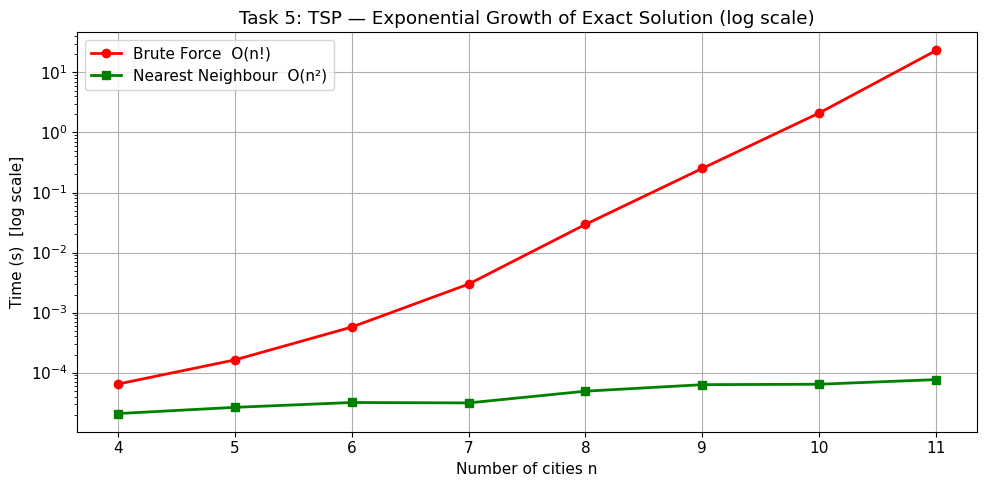

Saved → images/task5_tsp_growth.png


In [16]:
# ── Task 5: Exponential-growth plot ───────────────────────────────────────────
print('Measuring exponential growth of Brute-Force TSP …')
growth_n  = list(range(4, 12))
bf_times, nn_times2 = [], []

for n in growth_n:
    d, _ = random_dist_matrix(n, seed=n*7)
    t = time.perf_counter(); tsp_brute_force(d);       bf_times.append(time.perf_counter()-t)
    t = time.perf_counter(); tsp_nearest_neighbour(d); nn_times2.append(time.perf_counter()-t)
    print(f'  n={n}  BF={bf_times[-1]:.4f}s  NN={nn_times2[-1]:.6f}s')

plt.figure(figsize=(10, 5))
plt.plot(growth_n, bf_times,  'r-o', linewidth=2, label='Brute Force  O(n!)')
plt.plot(growth_n, nn_times2, 'g-s', linewidth=2, label='Nearest Neighbour  O(n²)')
plt.yscale('log')
plt.title('Task 5: TSP — Exponential Growth of Exact Solution (log scale)')
plt.xlabel('Number of cities n')
plt.ylabel('Time (s)  [log scale]')
plt.legend()
plt.tight_layout()
plt.savefig('images/task5_tsp_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → images/task5_tsp_growth.png')

**Task 5 Observations:**
- **Brute Force**: Correct and exact but O(n!) — time roughly multiplies by n with each added city. Infeasible beyond ~11 cities.
- **Held-Karp**: Still exponential (O(2ⁿ)) but vastly better than n! — feasible up to ~20 cities.
- **Nearest Neighbour**: Runs in O(n²) and gives a good approximate tour (usually within 20% of optimal); used in real-world logistics as a fast starting heuristic.
- The log-scale plot makes the O(n!) vs O(n²) gap unmistakable — this is why TSP is classified as NP-Hard.

---
## Final Summary

### Algorithm Comparison Table

| Task | Algorithm | Paradigm | Time | Space | Optimal |
|------|-----------|----------|------|-------|---------|
| 1 | Binary Search | D&C | O(log n) | O(1) | ✓ |
| 1 | Merge Sort | D&C | O(n log n) | O(n) | ✓ |
| 1 | Quick Sort | D&C | O(n log n) avg | O(log n) | ✓ |
| 1 | Max Subarray | D&C | O(n log n) | O(log n) | ✓ |
| 2 | Bubble Sort | Brute | O(n²) | O(1) | ✓ |
| 2 | Insertion Sort | Brute | O(n²) | O(1) | ✓ |
| 2 | Selection Sort | Brute | O(n²) | O(1) | ✓ |
| 3 | Activity Selection | Greedy | O(n log n) | O(n) | ✓ |
| 3 | Fractional Knapsack | Greedy | O(n log n) | O(n) | ✓ |
| 3 | Huffman Encoding | Greedy | O(n log n) | O(n) | ✓ |
| 3 | Coin Change | Greedy | O(d) | O(d) | ✓* |
| 4 | 0/1 Knapsack | DP | O(n·W) | O(n·W) | ✓ |
| 4 | LCS | DP | O(m·n) | O(m·n) | ✓ |
| 4 | Matrix Chain | DP | O(n³) | O(n²) | ✓ |
| 4 | Fibonacci (DP) | DP | O(n) | O(n) | ✓ |
| 5 | TSP Brute Force | Exhaustive | O(n!) | O(n) | ✓ |
| 5 | TSP Held-Karp | DP | O(2ⁿ·n²) | O(2ⁿ·n) | ✓ |
| 5 | TSP Nearest Neighbour | Greedy | O(n²) | O(n) | ✗ (approx) |

\* Greedy coin change is optimal only for canonical coin systems.

### Trade-off Analysis

- **0/1 Knapsack** benefited most from DP over Greedy: items cannot be split, so locally optimal choices do not guarantee a global optimum — DP explores all sub-possibilities systematically.
- **Fractional Knapsack** is naturally suited to Greedy: the exchange argument proves that the value/weight ratio ordering is globally optimal when fractions are permitted.
- **TSP** highlights the hardest real-world trade-off: exact algorithms are computationally intractable; practical systems (Google Maps, DHL routing) use approximation heuristics and accept near-optimal solutions.

### Real-world Suitability
- **Divide & Conquer** → Database B-tree search, FFT for signal processing, distributed sort (MapReduce).
- **Greedy** → Network routing (Dijkstra, Prim), Huffman compression (ZIP, PNG), task scheduling in OS.
- **DP** → DNA sequence alignment (bioinformatics), speech recognition (Viterbi), spell checkers (edit distance).

### Recursion Depth Note
Python's default recursion limit is ~1 000. For Merge Sort / Quick Sort on very large inputs, use `sys.setrecursionlimit()` or rewrite iteratively. Tabulation-based DP avoids stack-overflow issues entirely.